# Clasp Queens: raw SMAC incumbent trajectories

This notebook reconstructs the incumbent that SMAC recorded at
every incumbent-change trial for all depths, PCA settings, and
SMAC seeds in `30_raw_run`.

Each incumbent is independently evaluated twice with surrogate
quantile seed 0: once over **all training instances** and once over
**all held-out test instances**. The figures are separated by
evaluation split so optimization performance and held-out
generalization are not conflated. Lower PAR10 is better.

Solid lines denote no PCA and dashed lines denote PCA=4. Colors
identify RF depth. Runs that did not reach 5,000 trials stop at
their actual native runhistory count. Every graph is shown first
on a linear scale and then again on a logarithmic performance
scale; the final train/test scatter uses logarithmic axes for both
performance dimensions.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

HERE = Path.cwd().resolve()
if not (HERE / "results").is_dir():
    HERE = (
        Path.cwd()
        / "experiments/aclib"
        / "clasp_queens_surrogate"
        / "30_raw_run"
    ).resolve()
ACLIB_ROOT = HERE.parents[1]
if str(ACLIB_ROOT) not in sys.path:
    sys.path.insert(0, str(ACLIB_ROOT))

from raw_run_analytics import (
    build_raw_run_analysis,
    plot_final_train_test,
    plot_incumbents_across_seeds,
    plot_incumbents_per_seed,
)

BENCHMARK_KEY = "clasp_queens"
DISPLAY_NAME = "Clasp Queens"
plt.rcParams.update({"figure.dpi": 120, "axes.grid": False})
print("Experiment:", HERE)

Experiment: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/clasp_queens_surrogate/30_raw_run


## Load, validate, and audit the current snapshot

The validator caches each unique incumbent configuration, so
rerunning the notebook only evaluates newly observed incumbents.
The first audit table reports the current native trial count and
number of incumbent changes for every run. `complete=False`
indicates a timed-out or currently unfinished 5,000-trial run.

In [2]:
analysis = build_raw_run_analysis(HERE, BENCHMARK_KEY)
display(analysis.run_summary.reset_index(drop=True))
print("Unique incumbent configurations:", analysis.trajectories["configuration_fingerprint"].nunique())
print("Training cache:", analysis.cache_files["training"])
print("Test cache:", analysis.cache_files["test"])

Training validation cache hit: 46 incumbent configurations.
Test validation cache hit: 46 incumbent configurations.


,pca_mode,pca_components,depth,smac_seed,finished_trials,recorded_trials,evaluated_configurations,incumbent_changes,final_incumbent_config_id,final_incumbent_trials,final_incumbent_instances,complete,available_training_instances,final_incumbent_instance_coverage_percent
0,pca_4,4.0,5,0,5000,5000,1640,10,1109,484,484,True,484,100.0
1,pca_4,4.0,5,1,5000,5000,3686,6,37,484,484,True,484,100.0
2,pca_4,4.0,10,0,5000,5000,2686,8,141,484,484,True,484,100.0
3,pca_4,4.0,10,1,5000,5000,3577,7,67,484,484,True,484,100.0
4,pca_4,4.0,20,0,5000,5000,2640,9,610,484,484,True,484,100.0
5,pca_4,4.0,20,1,5000,5000,1681,9,1245,484,484,True,484,100.0
6,pca_4,4.0,30,0,5000,5000,1771,9,418,484,484,True,484,100.0
7,pca_4,4.0,30,1,5000,5000,2020,7,203,484,484,True,484,100.0
8,pca_none,NaN,5,0,5000,5000,2824,7,115,484,484,True,484,100.0
9,pca_none,NaN,5,1,5000,5000,3173,7,39,484,484,True,484,100.0


Unique incumbent configurations: 46
Training cache: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/clasp_queens_surrogate/30_raw_run/analytics_cache/full_training_validation_qseed_0.json
Test cache: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/clasp_queens_surrogate/30_raw_run/analytics_cache/full_test_validation_qseed_0.json


## Native evaluation coverage per run

Each row below is one depth/PCA/SMAC-seed run.
`evaluated_configurations` counts distinct configuration IDs with
at least one completed native runhistory record; it is therefore
not the number of acquisition candidates considered internally.
`recorded_trials` counts all completed configuration-instance
evaluations in the runhistory.

The last-incumbent columns use the final configuration in SMAC's
native intensifier trajectory. They report how many completed
trials belong to that configuration and how many distinct
training instances those trials cover. The coverage percentage is
relative to the benchmark's complete training-instance set. In
these deterministic runs one trial normally corresponds to one
distinct instance, but both counts are retained so repetitions or
partial coverage remain visible.

In [3]:
coverage_columns = [
    "pca_mode", "depth", "smac_seed", "complete",
    "recorded_trials", "evaluated_configurations",
    "final_incumbent_config_id", "final_incumbent_trials",
    "final_incumbent_instances", "available_training_instances",
    "final_incumbent_instance_coverage_percent",
]
evaluation_coverage = analysis.run_summary[coverage_columns].copy()
evaluation_coverage["final_incumbent_instance_coverage_percent"] = (
    evaluation_coverage[
        "final_incumbent_instance_coverage_percent"
    ].round(2)
)
display(evaluation_coverage.reset_index(drop=True))

,pca_mode,depth,smac_seed,complete,recorded_trials,evaluated_configurations,final_incumbent_config_id,final_incumbent_trials,final_incumbent_instances,available_training_instances,final_incumbent_instance_coverage_percent
0,pca_4,5,0,True,5000,1640,1109,484,484,484,100.0
1,pca_4,5,1,True,5000,3686,37,484,484,484,100.0
2,pca_4,10,0,True,5000,2686,141,484,484,484,100.0
3,pca_4,10,1,True,5000,3577,67,484,484,484,100.0
4,pca_4,20,0,True,5000,2640,610,484,484,484,100.0
5,pca_4,20,1,True,5000,1681,1245,484,484,484,100.0
6,pca_4,30,0,True,5000,1771,418,484,484,484,100.0
7,pca_4,30,1,True,5000,2020,203,484,484,484,100.0
8,pca_none,5,0,True,5000,2824,115,484,484,484,100.0
9,pca_none,5,1,True,5000,3173,39,484,484,484,100.0


## Training-instance incumbent trajectories: one plot per seed

These plots answer how the incumbent selected during each SMAC run
performs when re-evaluated over every training instance. A step
occurs only when SMAC's recorded incumbent changes. Independent
full-training performance can rise at a step because SMAC makes
decisions from incrementally evaluated instance subsets. The
second set of figures repeats the comparison with a logarithmic
y-axis, making relative improvements near low PAR10 values easier
to distinguish.

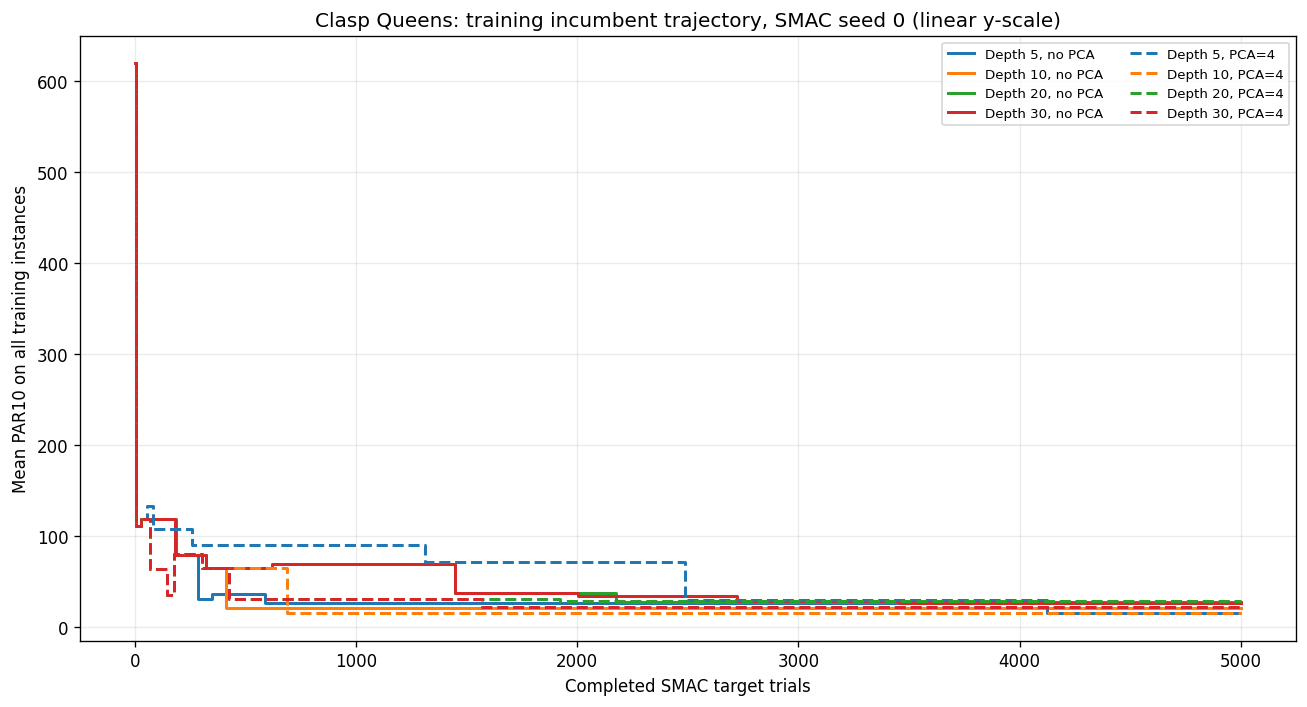

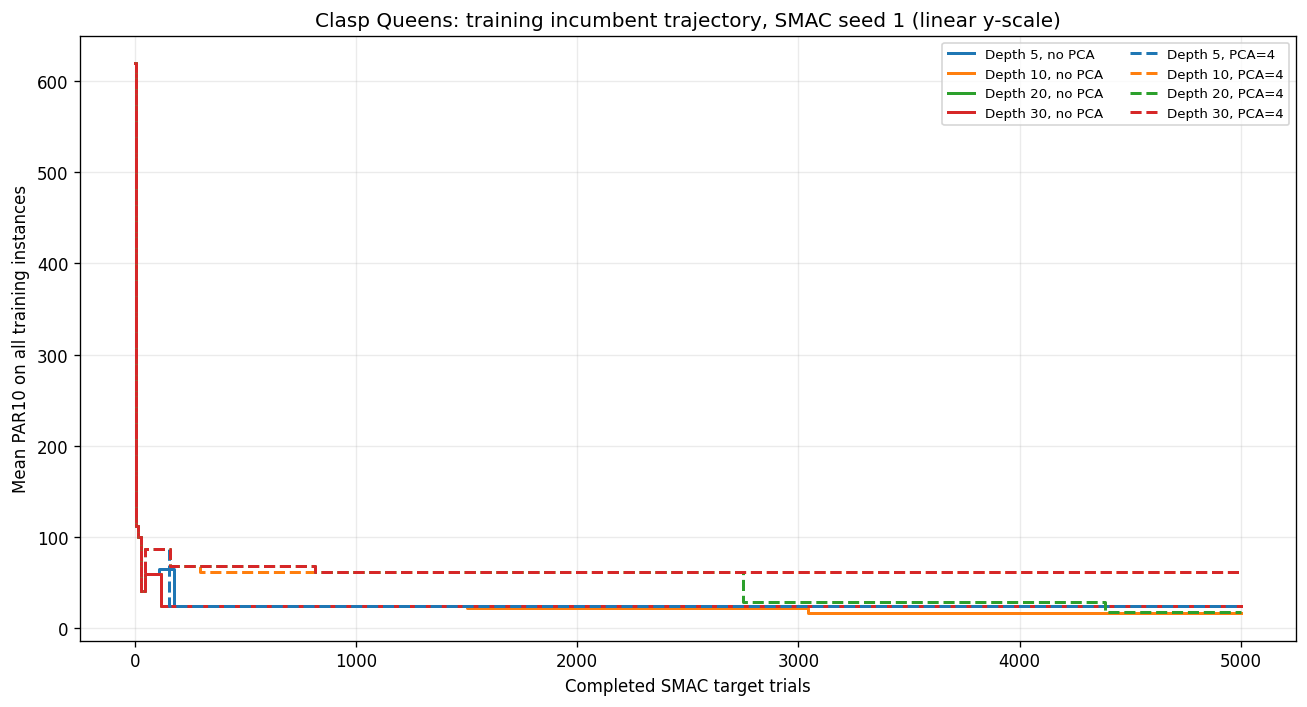

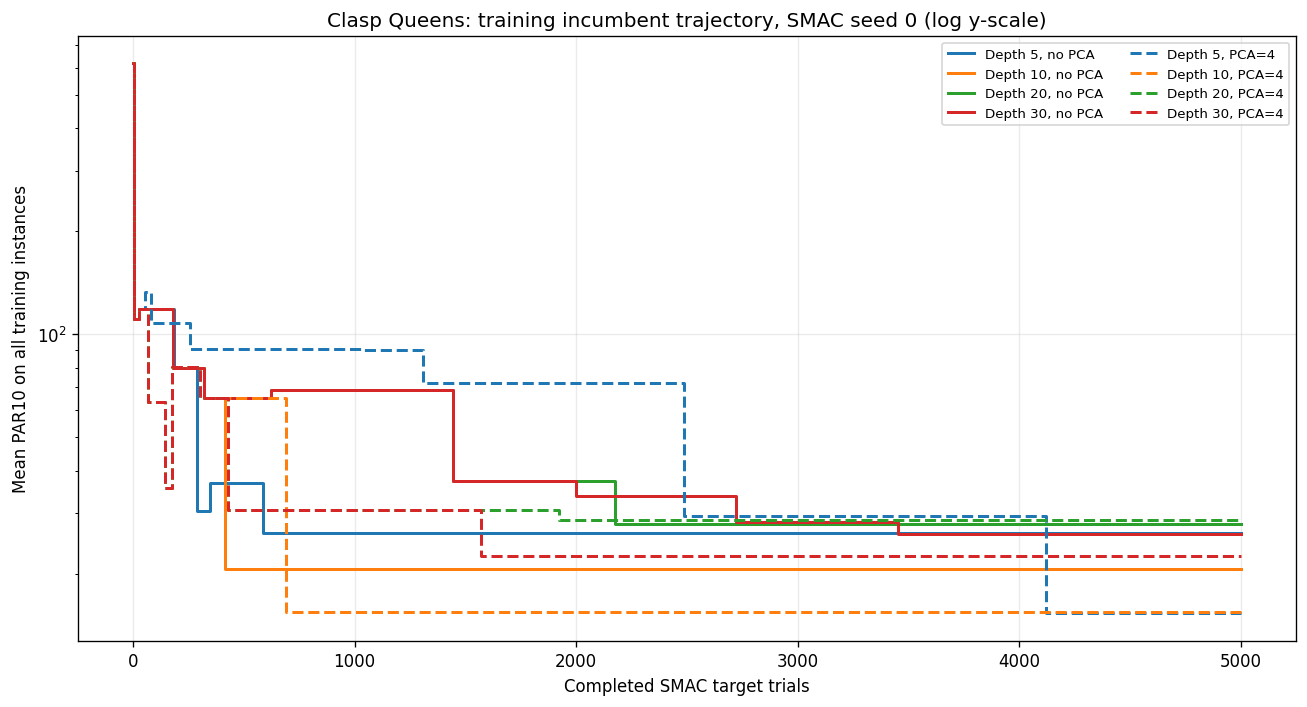

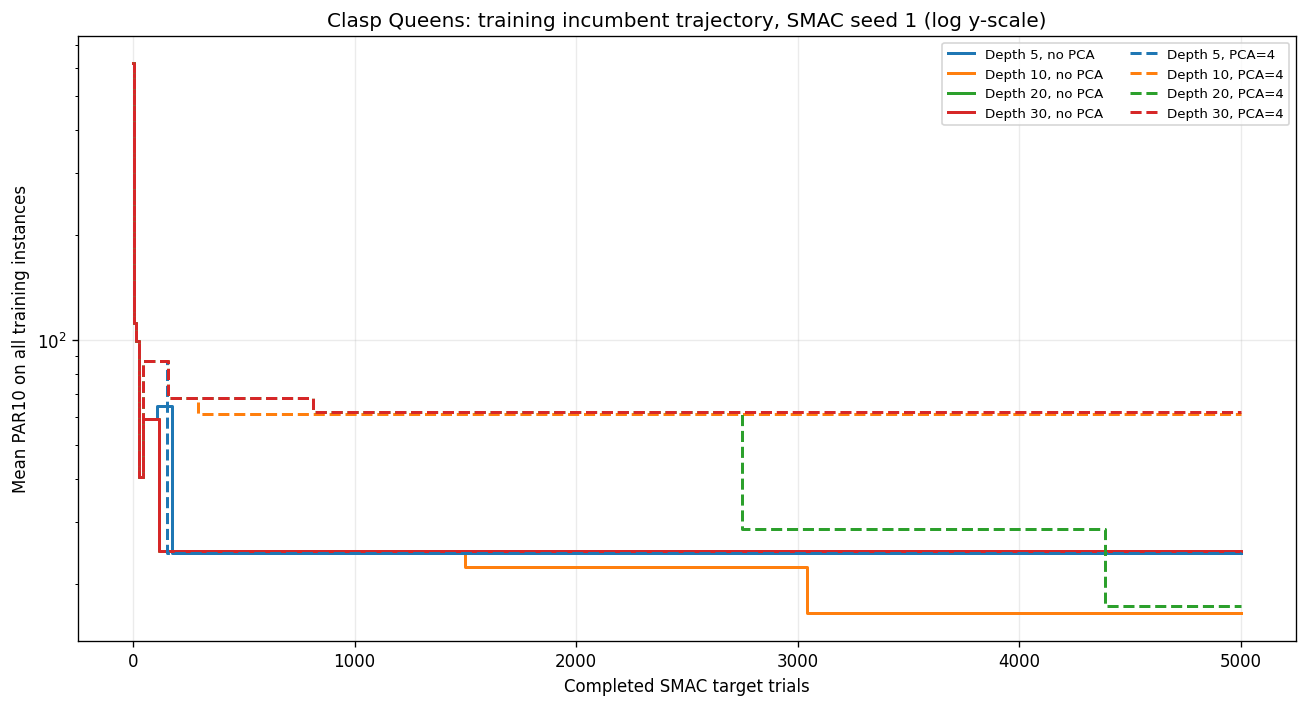

In [4]:
training_seed_figures = plot_incumbents_per_seed(analysis, "training")
for figure in training_seed_figures:
    display(figure)
    plt.close(figure)

training_seed_log_figures = plot_incumbents_per_seed(
    analysis, "training", yscale="log"
)
for figure in training_seed_log_figures:
    display(figure)
    plt.close(figure)

## Training-instance trajectories aggregated over both seeds

Each line is the mean of the two seed trajectories and its light
band is their minimum-to-maximum range. With only two seeds this is
deliberately a range, not a confidence interval. Every policy is
shown only up to the smaller finished-trial count of its two runs,
preventing a single surviving seed from determining the tail. The
logarithmic version below contains the identical trajectories and
seed ranges with only the y-axis transformation changed.

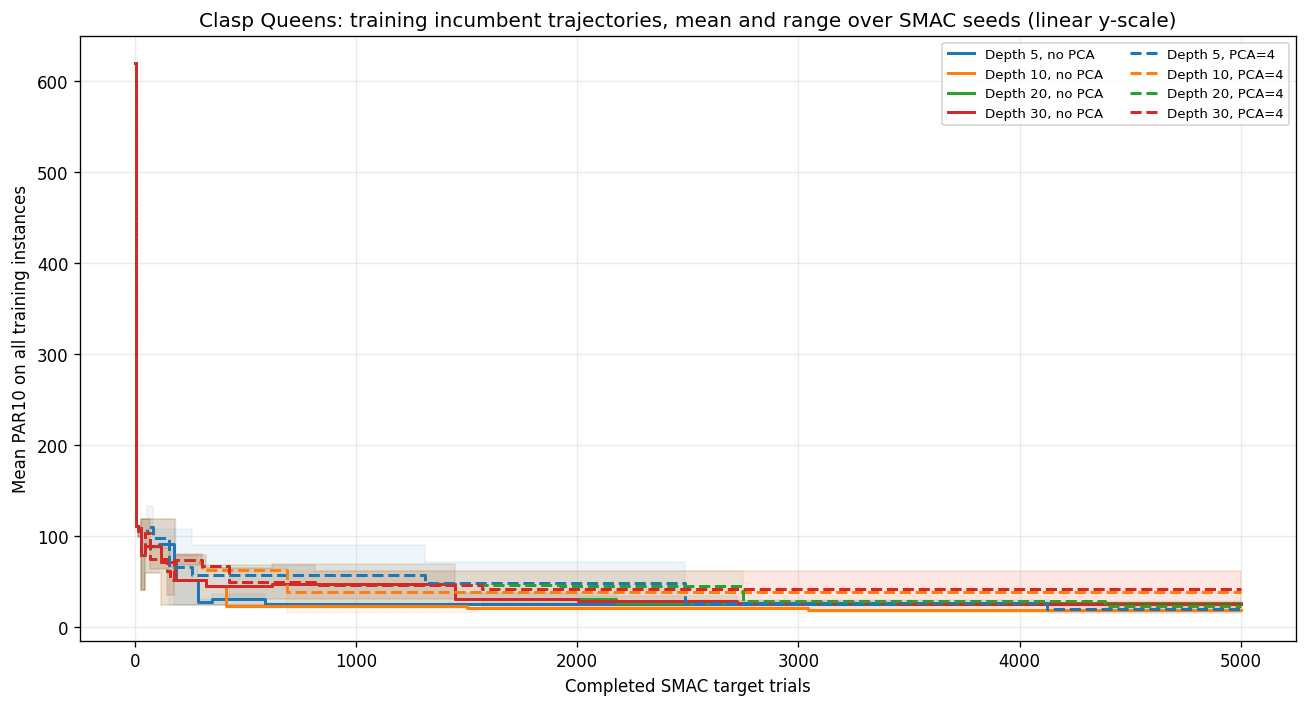

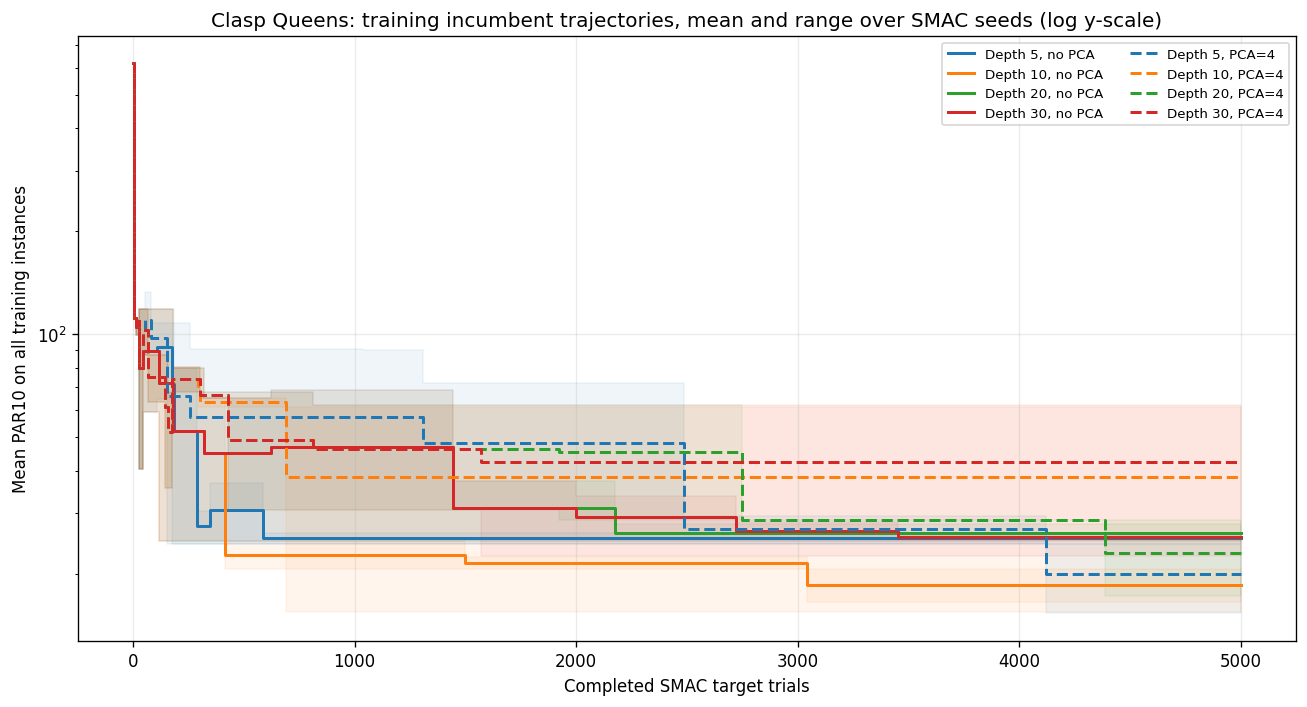

In [5]:
training_all_seeds = plot_incumbents_across_seeds(analysis, "training")
display(training_all_seeds)
plt.close(training_all_seeds)

training_all_seeds_log = plot_incumbents_across_seeds(
    analysis, "training", yscale="log"
)
display(training_all_seeds_log)
plt.close(training_all_seeds_log)

## Test-instance incumbent trajectories: one plot per seed

These are the same historical incumbents evaluated on every
held-out test instance. Test instances never influenced SMAC.
Comparing these figures with the training plots reveals whether
apparent optimization progress transfers out of sample. Linear
figures are followed by the same data on logarithmic y-axes.

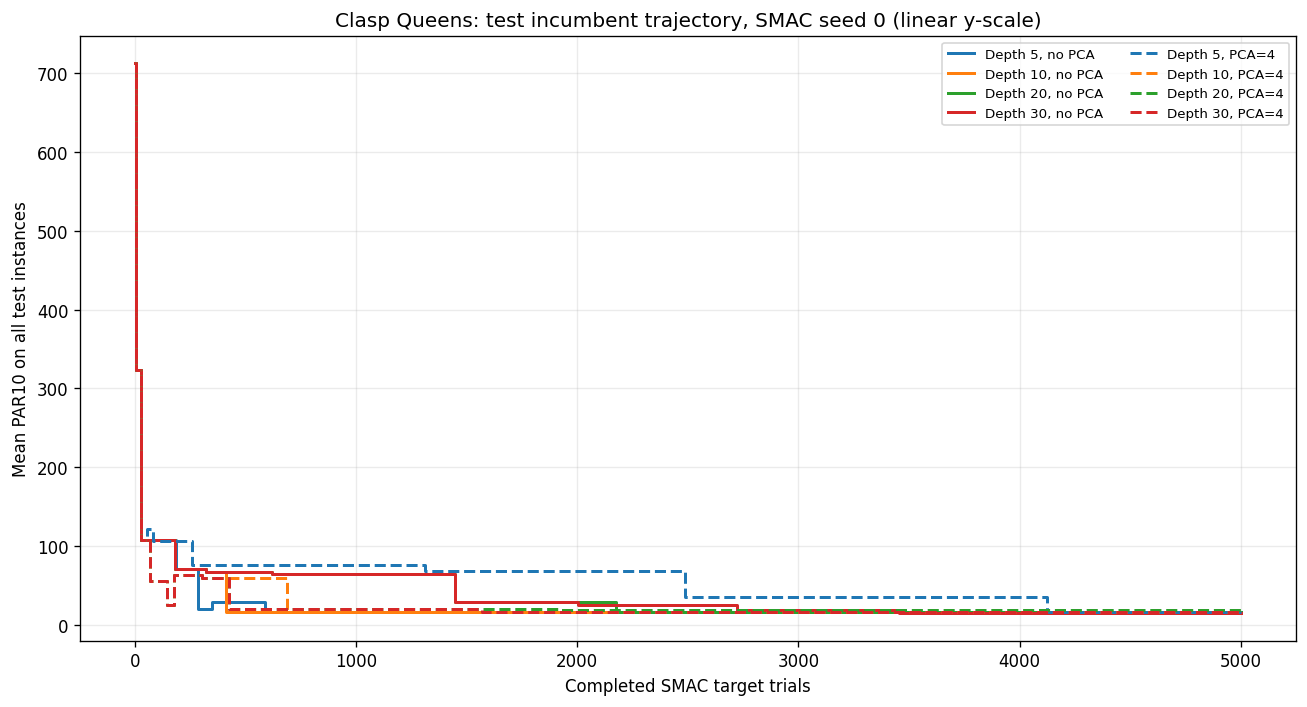

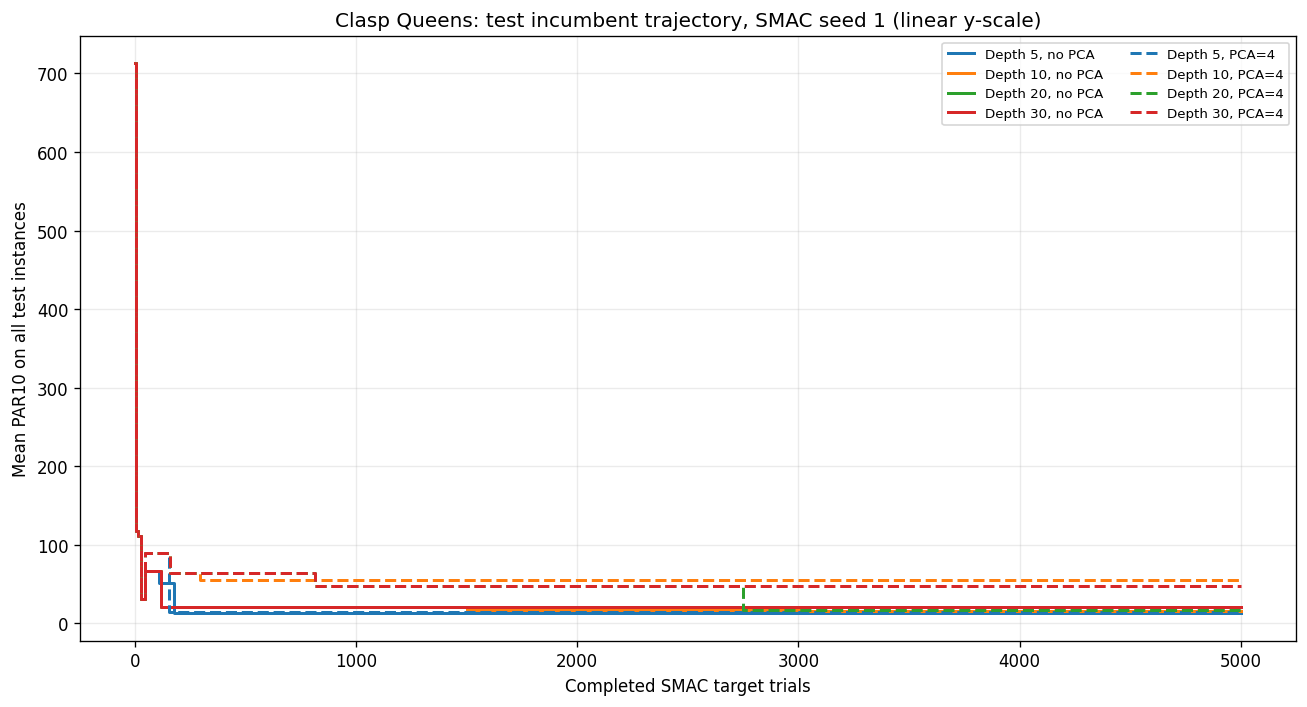

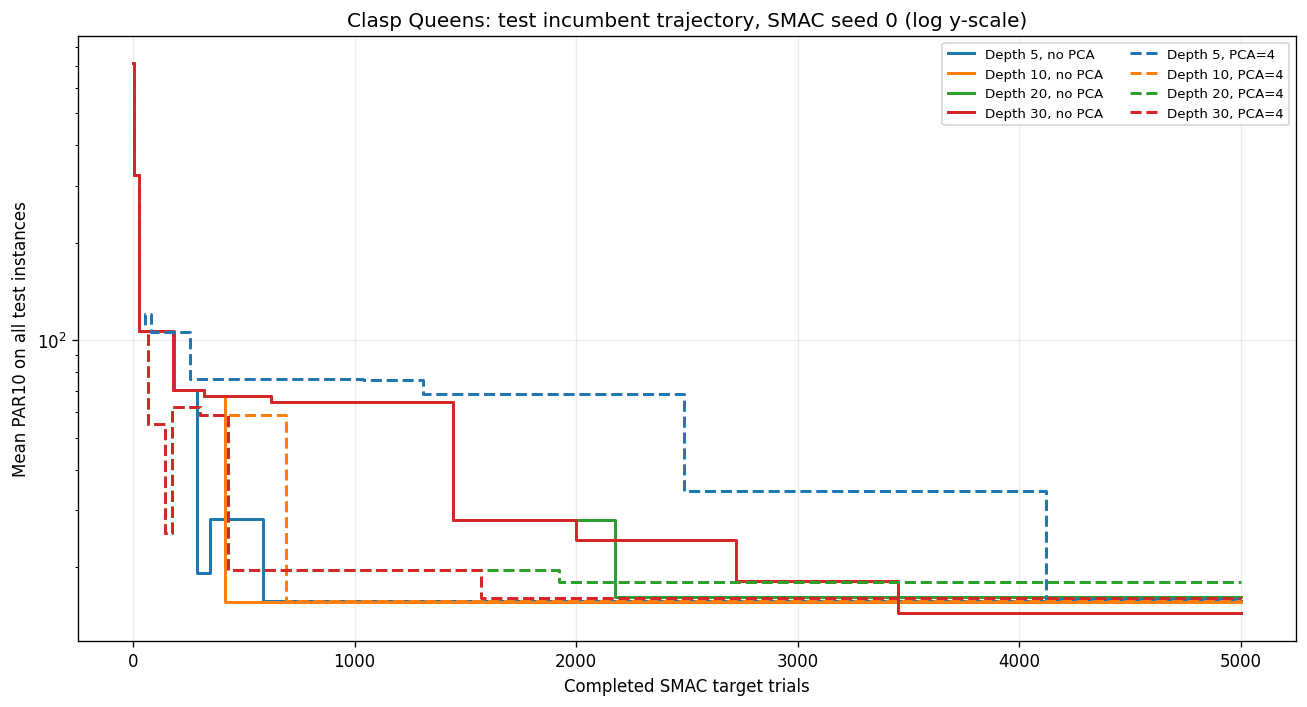

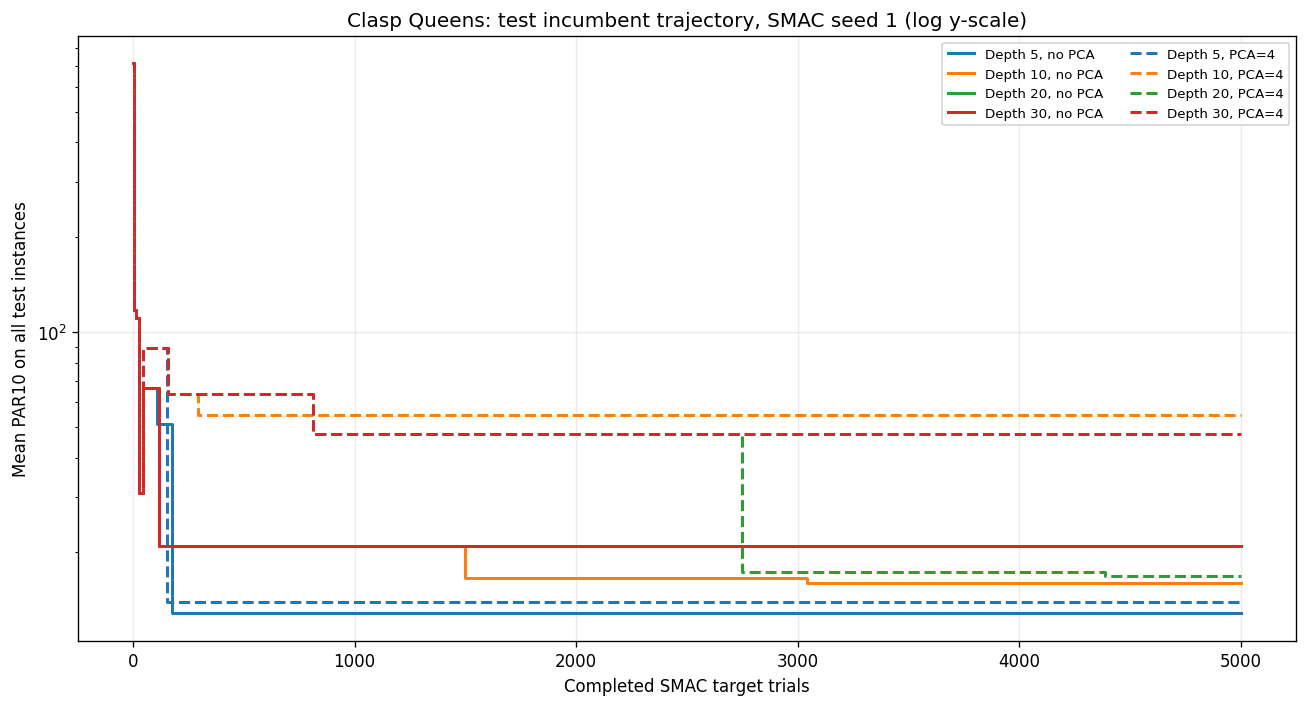

In [6]:
test_seed_figures = plot_incumbents_per_seed(analysis, "test")
for figure in test_seed_figures:
    display(figure)
    plt.close(figure)

test_seed_log_figures = plot_incumbents_per_seed(
    analysis, "test", yscale="log"
)
for figure in test_seed_log_figures:
    display(figure)
    plt.close(figure)

## Test-instance trajectories aggregated over both seeds

Lines are seed means and bands are seed ranges, restricted to the
common finished-trial horizon for each depth/PCA policy. This is
the held-out counterpart of the aggregated training plot. The
second graph repeats it with logarithmic performance scaling.

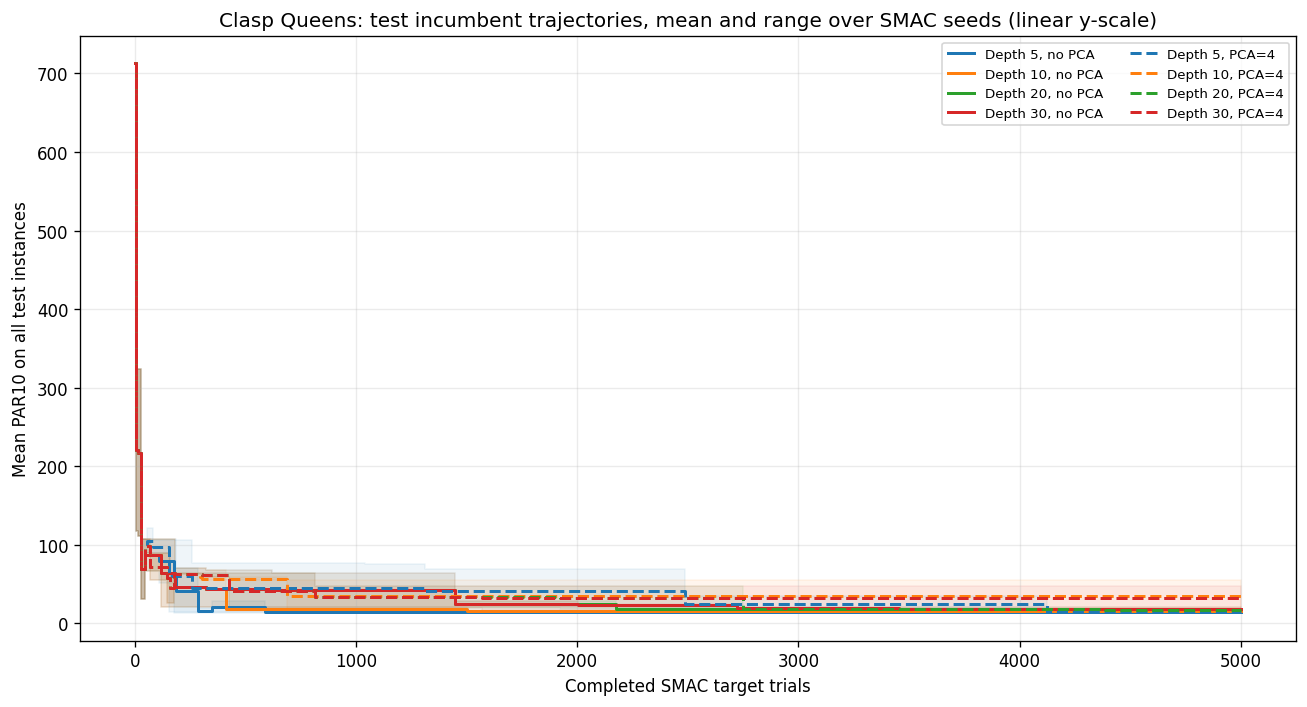

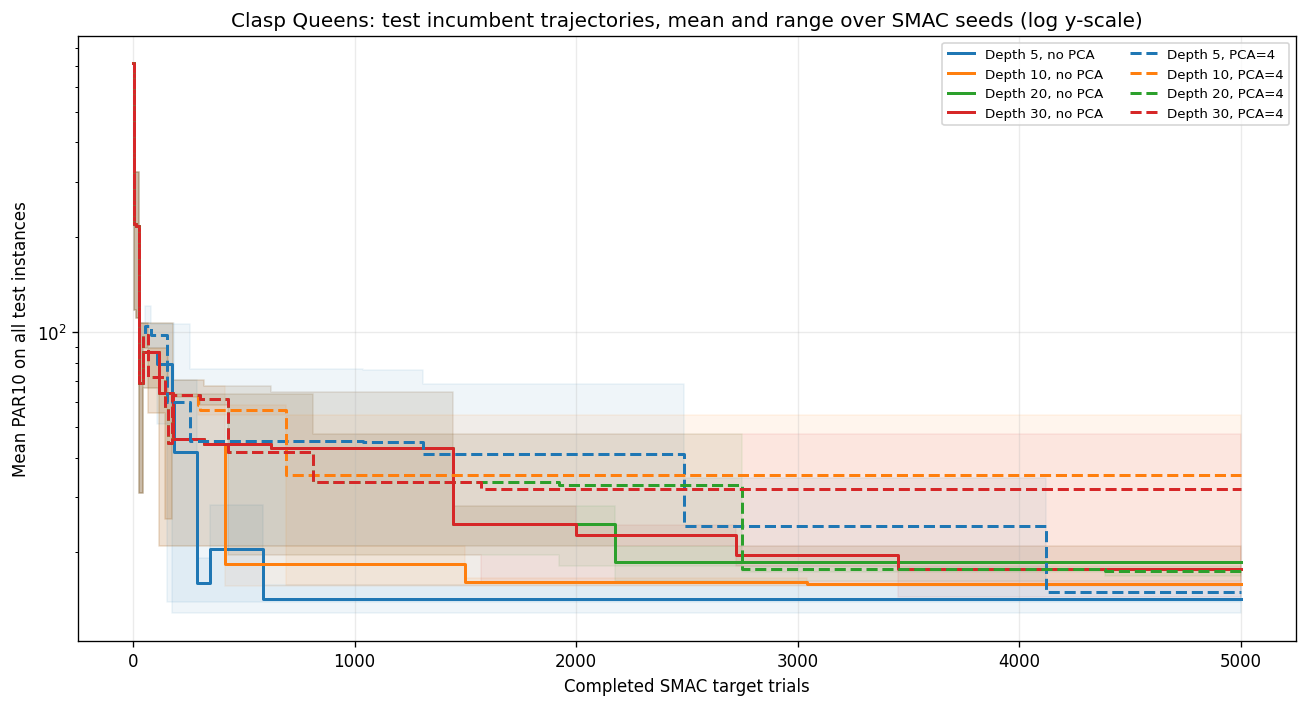

In [7]:
test_all_seeds = plot_incumbents_across_seeds(analysis, "test")
display(test_all_seeds)
plt.close(test_all_seeds)

test_all_seeds_log = plot_incumbents_across_seeds(
    analysis, "test", yscale="log"
)
display(test_all_seeds_log)
plt.close(test_all_seeds_log)

## Final incumbent: training versus test performance

Each point is one run's current final incumbent. The diagonal
denotes equal training and test PAR10. Distance from the diagonal
is a descriptive generalization gap, but train and test instance
sets can also differ intrinsically in difficulty. The second
scatter repeats the points with logarithmic training and test
axes.

,pca_mode,depth,smac_seed,finished_trials,training_mean_par10,test_mean_par10,test_minus_training_par10,training_timeouts,test_timeouts
0,pca_none,5,1,5000,24.477254,12.823803,-11.653451,2,0
1,pca_4,5,1,5000,24.451329,13.874755,-10.576573,2,0
2,pca_none,30,0,5000,26.181087,14.458733,-11.722355,2,0
3,pca_none,10,0,5000,20.585979,15.676576,-4.909403,1,0
4,pca_none,5,0,5000,26.263510,15.728571,-10.534940,2,0
5,pca_4,10,0,5000,15.439424,15.756535,0.317111,0,0
6,pca_none,10,1,5000,16.471847,15.978528,-0.493319,0,0
7,pca_4,5,0,5000,15.325241,16.018085,0.692844,0,0
8,pca_4,30,0,5000,22.455885,16.071856,-6.384029,1,0
9,pca_none,20,0,5000,27.867997,16.203858,-11.664139,2,0


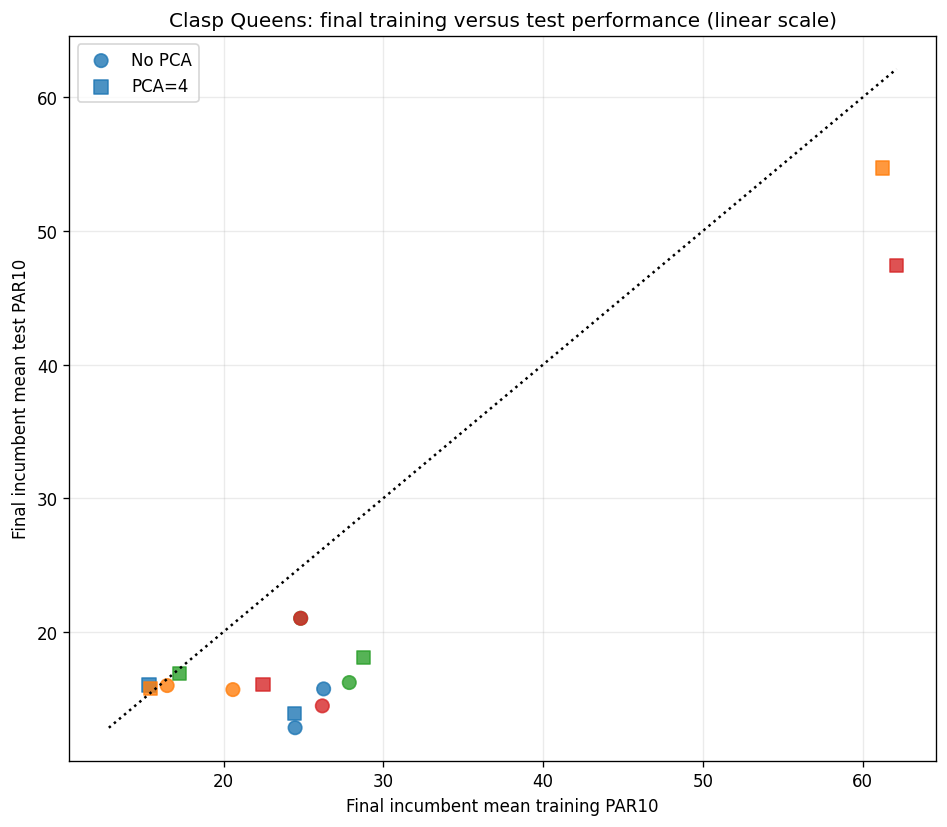

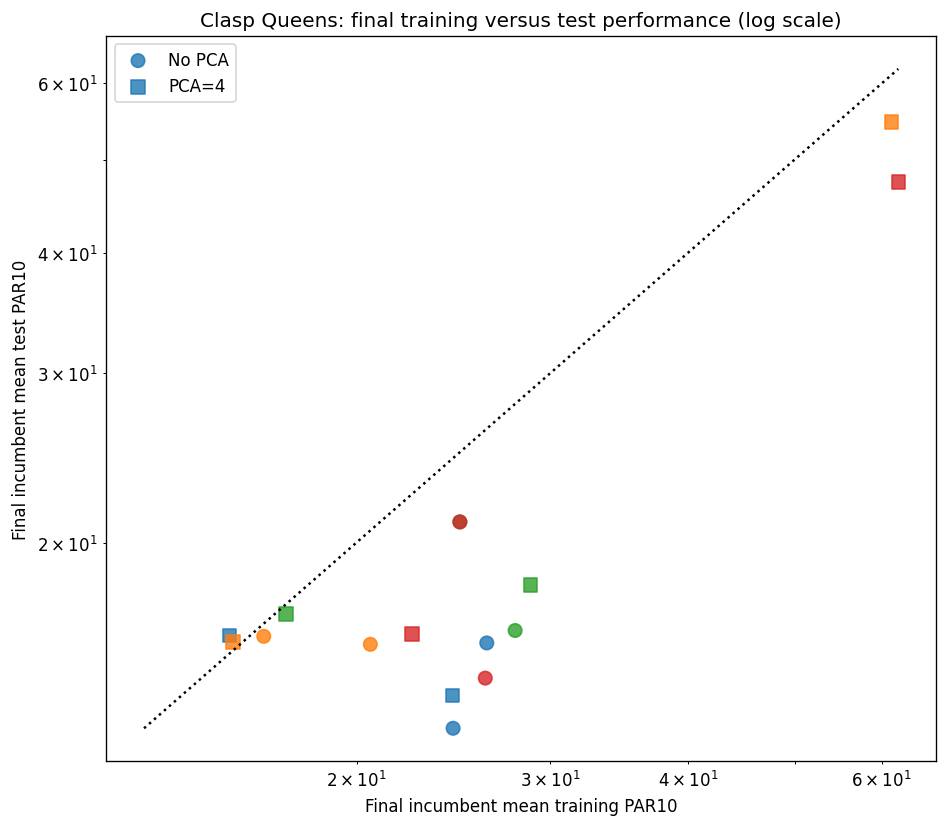

In [8]:
final_columns = [
    "pca_mode", "depth", "smac_seed", "finished_trials",
    "training_mean_par10", "test_mean_par10",
    "test_minus_training_par10",
    "training_timeouts", "test_timeouts",
]
final_table = analysis.final_incumbents[final_columns].sort_values(
    ["test_mean_par10", "training_mean_par10"]
)
display(final_table.reset_index(drop=True))
final_scatter = plot_final_train_test(analysis)
display(final_scatter)
plt.close(final_scatter)

final_log_scatter = plot_final_train_test(analysis, scale="log")
display(final_log_scatter)
plt.close(final_log_scatter)